# Titanic Survival - Exploratory Data Analysis

## Objective
This project explores the Titanic dataset to understand which factors
(gender, passenger class, age, family status, embarkation port) influenced
a passenger's chance of survival.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print(" All libraries imported successfully")

 All libraries imported successfully


In [25]:
df = sns.load_dataset('titanic')

print(" Dataset loaded successfully")
print(" Shape of dataset:",df.shape)

 Dataset loaded successfully
 Shape of dataset: (891, 15)


In [26]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Dataset Overview
- **Source:** Seaborn built-in Titanic dataset
- **Total Passengers:** 891
- **Key Columns:** survived, pclass, sex, age, sibsp, parch, fare, embarked

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [28]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [29]:
print("Shape:", df.shape)
print("Columns", df.columns.tolist())
print("Data Types:", df.dtypes)

Shape: (891, 15)
Columns ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']
Data Types: survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object


In [30]:
missing = df.isnull().sum()
print("missing values per colomn:")
print(missing[missing > 0])
print("Missing percentage:")
print(round(missing[missing > 0] / len(df) * 100, 2))

missing values per colomn:
age            177
embarked         2
deck           688
embark_town      2
dtype: int64
Missing percentage:
age            19.87
embarked        0.22
deck           77.22
embark_town     0.22
dtype: float64


In [31]:
print("survived")
print(df['survived'].value_counts())
print("survived percentage:")
print(round(df['survived'].value_counts(normalize = True) * 100 , 2))

survived
survived
0    549
1    342
Name: count, dtype: int64
survived percentage:
survived
0    61.62
1    38.38
Name: proportion, dtype: float64


In [32]:
print("Gender:")
print(df['sex'].value_counts())
print("Passanger class:")
print(df['pclass'].value_counts().sort_index())
print("Age details:")
print(df['age'].describe())
print("\nFare statistics:")
print(df['fare'].describe())

Gender:
sex
male      577
female    314
Name: count, dtype: int64
Passanger class:
pclass
1    216
2    184
3    491
Name: count, dtype: int64
Age details:
count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: age, dtype: float64

Fare statistics:
count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: fare, dtype: float64


In [33]:
print("Survival rate by gender:")
print(df.groupby('sex')['survived'].mean().round(2))

print("\nSurvival rate by passenger class:")
print(df.groupby('pclass')['survived'].mean().round(2))

print("\nSurvival rate by embarkation:")
print(df.groupby('embarked')['survived'].mean().round(2))

Survival rate by gender:
sex
female    0.74
male      0.19
Name: survived, dtype: float64

Survival rate by passenger class:
pclass
1    0.63
2    0.47
3    0.24
Name: survived, dtype: float64

Survival rate by embarkation:
embarked
C    0.55
Q    0.39
S    0.34
Name: survived, dtype: float64


In [34]:
print("Missing ages BEFORE:", df['age'].isnull().sum())
median_age = df['age'].median()
print("Median age we'll use:", median_age)
df['age'] = df['age'].fillna(median_age)
print("Missing ages AFTER:", df['age'].isnull().sum())

Missing ages BEFORE: 177
Median age we'll use: 28.0
Missing ages AFTER: 0


In [35]:
print("Columns before:", df.shape[1])
df = df.drop(columns=['deck'])
print("Columns after:", df.shape[1])
print("'deck' column removed ")

Columns before: 15
Columns after: 14
'deck' column removed 


In [36]:
most_common = df['embarked'].mode()[0]
print("Most common:", most_common)

df['embarked'] = df['embarked'].fillna(most_common)
df = df.drop(columns=['embark_town'])
print("Missing embarked AFTER:", df['embarked'].isnull().sum())

Most common: S
Missing embarked AFTER: 0


In [37]:
print("Remaining missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("Dataset shape now:", df.shape)
print("Data is clean and ready for visualization")

Remaining missing values:
Series([], dtype: int64)
Dataset shape now: (891, 13)
Data is clean and ready for visualization


## Data Cleaning Summary
- Filled missing `age` values with the median age
- Filled missing `embarked` values with the most common port
- Dropped `deck` column due to ~77% missing data
- Dropped `embark_town` as it duplicated `embarked`

/tmp/ipykernel_1821/2699878071.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='survived', data=df, palette='Set2')


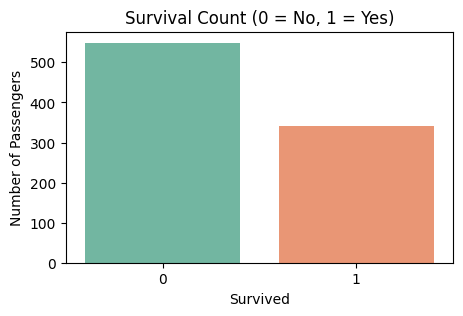

In [38]:
plt.figure(figsize=(5, 3))
sns.countplot(x='survived', data=df, palette='Set2')

plt.title('Survival Count (0 = No, 1 = Yes)')
plt.xlabel('Survived')
plt.ylabel('Number of Passengers')
plt.show()

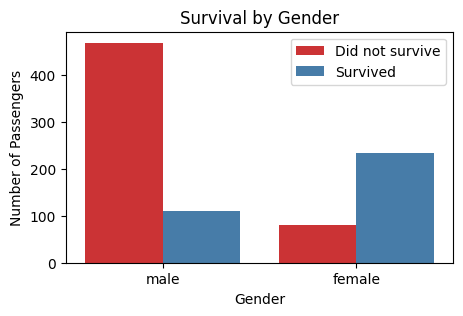

In [39]:
plt.figure(figsize=(5, 3))
sns.countplot(x='sex', hue='survived', data=df, palette='Set1')

plt.title('Survival by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')
plt.legend(['Did not survive', 'Survived'])
plt.show()

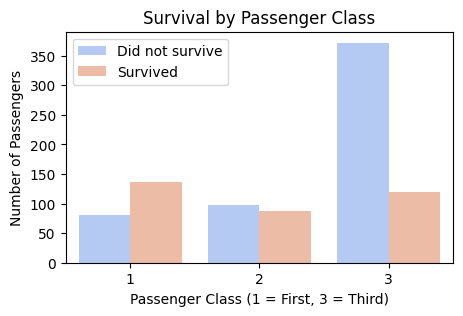

In [40]:
plt.figure(figsize=(5, 3))
sns.countplot(x='pclass', hue='survived', data=df, palette='coolwarm')

plt.title('Survival by Passenger Class')
plt.xlabel('Passenger Class (1 = First, 3 = Third)')
plt.ylabel('Number of Passengers')
plt.legend(['Did not survive', 'Survived'])
plt.show()

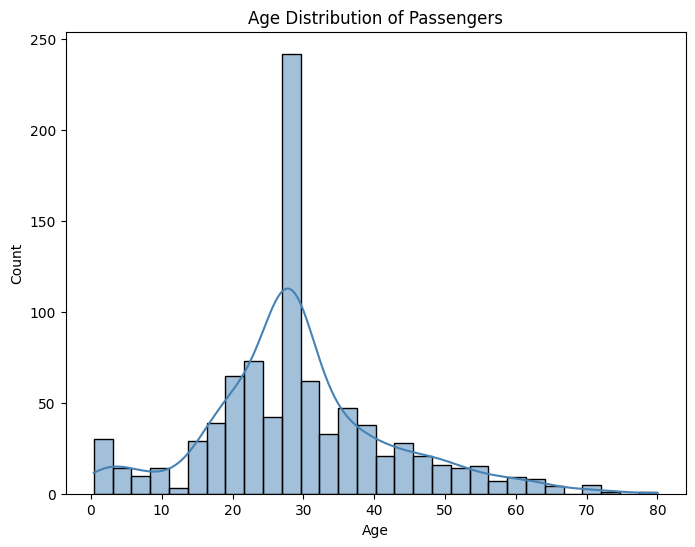

In [41]:
plt.figure(figsize=(8, 6))
sns.histplot(df['age'], bins=30, kde=True, color='steelblue')

plt.title('Age Distribution of Passengers')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

/tmp/ipykernel_1821/1458070483.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='survived', y='age', data=df, palette='pastel')


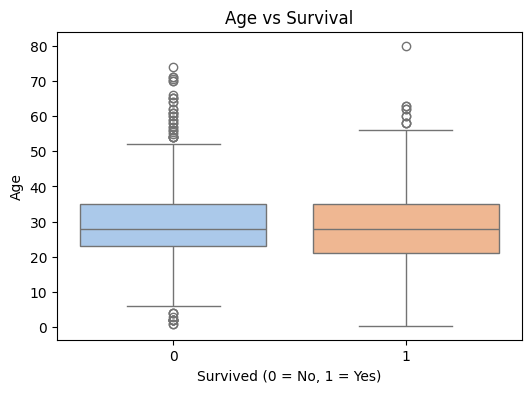

In [42]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='survived', y='age', data=df, palette='pastel')

plt.title('Age vs Survival')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Age')
plt.show()

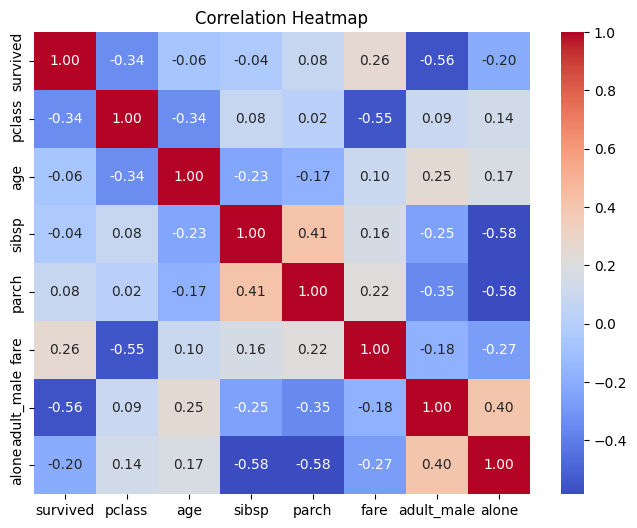

In [43]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

In [44]:
alone_survival = round(df.groupby('alone')['survived'].mean() * 100, 1)
print(alone_survival)

alone
False    50.6
True     30.4
Name: survived, dtype: float64


In [45]:
embarked_survival = round(df.groupby('embarked')['survived'].mean() * 100, 1)
print(embarked_survival)

embarked
C    55.4
Q    39.0
S    33.9
Name: survived, dtype: float64


##Insights
1. Adult male to survived have a high negative value meaning gender played and important role in correlation with survival

2. Alone survival percentage of true is 30.4 % meaning that being alone affected the survival factor also

3. Passengers who embarked from Cherbourg (C) had the highest survival rate, while Southampton (S) had the lowest. This is likely not due to the port itself, but because Cherbourg had a higher proportion of 1st class passengers — linking back to the class survival pattern.

4. Passengers marked as "alone" (0 siblings/spouse, 0 parents/children) had lower survival rates, reinforcing that traveling with family positively impacted survival chances.

## Final Conclusion
Survival on the Titanic was not random — it was strongly shaped by gender,
class, and social factors. Women and 1st class passengers had significantly
higher survival rates, largely due to the "women and children first"
evacuation policy and better access to lifeboats. Passengers traveling alone,
without family support, also had lower survival rates compared to those with
companions. These patterns reflect the social hierarchy and human behavior
during a crisis, not just random chance.